# Naive Bayes Training - Sentimentanalyse Produktrezensionen

Mehrklassen-Klassifizierung (1-5 Sterne) mit TF-IDF und Naive Bayes

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# KONFIGURATION: Project Root
# ============================================================
PROJECT_ROOT = Path("../")

# Pfade (relativ zum PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data" / "splits"
TRAIN_FILE = DATA_DIR / "train_0_50000_80_0_20.jsonl"
TEST_FILE = DATA_DIR / "test_0_50000_80_0_20.jsonl"
MODEL_DIR = PROJECT_ROOT / "results" / "bayes" / "models"
METRICS_DIR = PROJECT_ROOT / "results" / "bayes"/ "metrics"

# Ordner erstellen
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Pfade pruefen
print(f"PROJECT_ROOT: {PROJECT_ROOT.resolve()}")
print(f"TRAIN_FILE existiert: {TRAIN_FILE.exists()}")
print(f"TEST_FILE existiert: {TEST_FILE.exists()}")
print("✓ Imports und Pfade initialisiert")

PROJECT_ROOT: C:\Develop\Python\nlp
TRAIN_FILE existiert: True
TEST_FILE existiert: True
✓ Imports und Pfade initialisiert


## Hyperparameter-Konfiguration

Alle tuningwürdigen Parameter zentral an einer Stelle.

| Parameter | Beschreibung | Typische Werte |
|---|---|---|
| `ALPHA` | Laplace-Smoothing (MultinomialNB) | 0.01 – 10.0 |
| `MAX_FEATURES` | Max. Anzahl TF-IDF-Features | 1.000 – 50.000 |
| `MIN_DF` | Min. Dokumenthäufigkeit eines Terms | 1 – 10 |
| `MAX_DF` | Max. Dokumenthäufigkeit eines Terms | 0.7 – 1.0 |
| `NGRAM_RANGE` | Uni- und/oder Bigramme | (1,1), (1,2) |
| `STOP_WORDS` | Stoppwörter entfernen | 'english', None |
| `SUBLINEAR_TF` | Logarithmische TF-Skalierung | True, False |
| `USE_RESAMPLING` | Klassenungleichgewicht ausgleichen | True, False |

In [2]:
# ============================================================
# HYPERPARAMETER – hier anpassen!
# ============================================================

# MultinomialNB
ALPHA = 0.01            # Laplace-Smoothing; kleiner = weniger Glättung

# TF-IDF Vektorizer
MAX_FEATURES = 10000     # Anzahl der Features (Vokabular-Größe)
MIN_DF = 2              # Term muss in mind. N Dokumenten vorkommen
MAX_DF = 0.95           # Term darf in höchstens X% der Dokumente vorkommen
NGRAM_RANGE = (1, 2)    # (1,1) = Unigramme; (1,2) = Uni- + Bigramme
STOP_WORDS = 'english'  # Stoppwörter: 'english' oder None
SUBLINEAR_TF = False    # True = log(TF) statt TF; oft besser bei langen Texten

# Resampling
USE_RESAMPLING = False   # True = RandomOverSampler zum Ausgleich der Klassen

print("Aktuelle Hyperparameter:")
print(f"  ALPHA          = {ALPHA}")
print(f"  MAX_FEATURES   = {MAX_FEATURES}")
print(f"  MIN_DF         = {MIN_DF}")
print(f"  MAX_DF         = {MAX_DF}")
print(f"  NGRAM_RANGE    = {NGRAM_RANGE}")
print(f"  STOP_WORDS     = {STOP_WORDS}")
print(f"  SUBLINEAR_TF   = {SUBLINEAR_TF}")
print(f"  USE_RESAMPLING = {USE_RESAMPLING}")

Aktuelle Hyperparameter:
  ALPHA          = 0.01
  MAX_FEATURES   = 10000
  MIN_DF         = 2
  MAX_DF         = 0.95
  NGRAM_RANGE    = (1, 2)
  STOP_WORDS     = english
  SUBLINEAR_TF   = False
  USE_RESAMPLING = False


## 1. Daten laden

In [3]:
def load_data(filepath):
    """Lädt JSONL-Datei und extrahiert title, text, rating"""
    texts = []
    ratings = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            # Kombiniere title und text
            combined_text = f"{data['title']} {data['text']}"
            texts.append(combined_text)
            ratings.append(int(data['rating']))
    
    return texts, ratings

print("Loading training data...")
X_train_texts, y_train = load_data(TRAIN_FILE)
print(f"✓ Trainings-Samples: {len(X_train_texts)}")

print("Loading test data...")
X_test_texts, y_test = load_data(TEST_FILE)
print(f"✓ Test-Samples: {len(X_test_texts)}")

Loading training data...
✓ Trainings-Samples: 160000
Loading test data...
✓ Test-Samples: 40000


## 2. Klassenverteilung prüfen

In [4]:
# Class Distribution
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

print("\nTraining Set Distribution:")
print(train_dist)
print(f"\nTest Set Distribution:")
print(test_dist)


Training Set Distribution:
1      9732
2      6861
3     13470
4     26824
5    103113
Name: count, dtype: int64

Test Set Distribution:
1     2600
2     1634
3     3159
4     6145
5    26462
Name: count, dtype: int64


## 3. TF-IDF Vektorisierung

In [5]:
def preprocess_texts(texts):
    """TF-IDF Vektorisierung mit den konfigurierten Hyperparametern"""
    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES,
        min_df=MIN_DF,
        max_df=MAX_DF,
        lowercase=True,
        stop_words=STOP_WORDS,
        ngram_range=NGRAM_RANGE,
        sublinear_tf=SUBLINEAR_TF
    )
    X = vectorizer.fit_transform(texts)
    return X, vectorizer

print("Vektorisierung (TF-IDF)...")
X_train, vectorizer = preprocess_texts(X_train_texts)
X_test = vectorizer.transform(X_test_texts)
print(f"✓ Feature-Dimension: {X_train.shape[1]}")
print(f"✓ Training Matrix Shape: {X_train.shape}")
print(f"✓ Test Matrix Shape: {X_test.shape}")

Vektorisierung (TF-IDF)...
✓ Feature-Dimension: 10000
✓ Training Matrix Shape: (160000, 10000)
✓ Test Matrix Shape: (40000, 10000)


In [6]:
# Optional: Daten rebalancieren für bessere Performance
if USE_RESAMPLING:
    from imblearn.over_sampling import RandomOverSampler
    ros = RandomOverSampler(random_state=42)
    X_train_final, y_train_final = ros.fit_resample(X_train, y_train)
    print(f"Original Training-Samples:  {X_train.shape[0]}")
    print(f"Resampled Training-Samples: {X_train_final.shape[0]}")
else:
    X_train_final, y_train_final = X_train, y_train
    print(f"Resampling deaktiviert. Training-Samples: {X_train_final.shape[0]}")

Resampling deaktiviert. Training-Samples: 160000


## 4. Naive Bayes Training

In [7]:
def train_model(X_train, y_train):
    """Trainiere Naive Bayes Modell mit den konfigurierten Hyperparametern"""
    model = MultinomialNB(alpha=ALPHA)
    model.fit(X_train, y_train)
    return model

print("Modell-Training...")
model = train_model(X_train_final, y_train_final)
print("✓ Training abgeschlossen")

Modell-Training...
✓ Training abgeschlossen


## 5. Evaluierung

In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

class_names = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']

print(f"\n{'='*60}")
print(f"EVALUIERUNG")
print(f"{'='*60}")
print(f"Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


EVALUIERUNG
Accuracy: 0.7040

Classification Report:
              precision    recall  f1-score   support

      1 Star       0.68      0.47      0.56      2600
     2 Stars       0.31      0.03      0.06      1634
     3 Stars       0.46      0.12      0.19      3159
     4 Stars       0.41      0.09      0.14      6145
     5 Stars       0.72      0.98      0.83     26462

    accuracy                           0.70     40000
   macro avg       0.52      0.34      0.36     40000
weighted avg       0.64      0.70      0.63     40000



## 6. Confusion Matrix Visualisierung

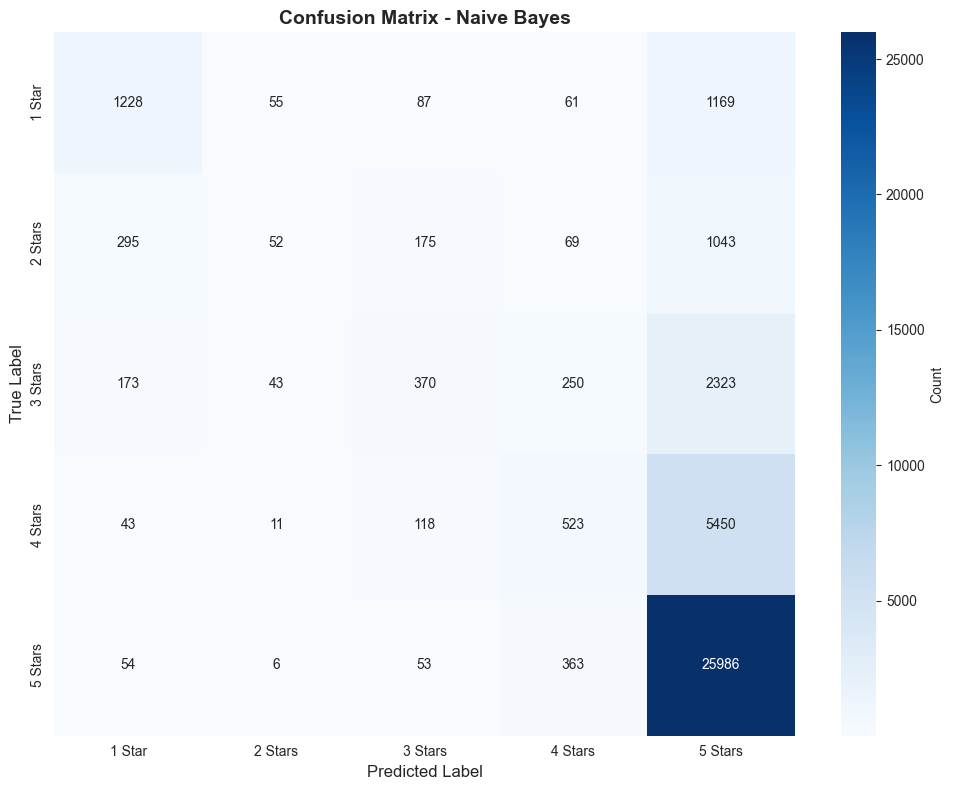

✓ Confusion Matrix gespeichert


In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Naive Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(METRICS_DIR / 'confusion_matrix_naive_bayes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Confusion Matrix gespeichert")

## 7. Modell und Ergebnisse speichern

In [10]:
# Metriken speichern
results = {
    'accuracy': float(accuracy),
    'confusion_matrix': conf_matrix.tolist(),
    'num_test_samples': len(y_test),
    'classes': class_names,
    'hyperparameters': {
        'alpha': ALPHA,
        'max_features': MAX_FEATURES,
        'min_df': MIN_DF,
        'max_df': MAX_DF,
        'ngram_range': list(NGRAM_RANGE),
        'stop_words': STOP_WORDS,
        'sublinear_tf': SUBLINEAR_TF,
        'use_resampling': USE_RESAMPLING
    }
}
with open(METRICS_DIR / "naive_bayes_metrics.json", 'w') as f:
    json.dump(results, f, indent=2)

# CSV für Vergleiche
hyperparams_str = (
    f"alpha: {ALPHA} | max_features: {MAX_FEATURES} | min_df: {MIN_DF} | "
    f"max_df: {MAX_DF} | ngram_range: {NGRAM_RANGE} | stop_words: {STOP_WORDS} | "
    f"sublinear_tf: {SUBLINEAR_TF} | resampling: {USE_RESAMPLING}"
)
pd.DataFrame({
    'Model':          ['Naive Bayes'],
    'Accuracy':       [accuracy],
    'Val_Accuracy':   [None],
    'Train_Samples':  [None],
    'Test_Samples':   [len(y_test)],
    'Hyperparameters': [hyperparams_str]
}).to_csv(METRICS_DIR / "naive_bayes_results.csv", index=False, sep=';')

with open(MODEL_DIR / "naive_bayes_model.pkl", 'wb') as f:
    pickle.dump(model, f)
with open(MODEL_DIR / "vectorizer.pkl", 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"✓ Metriken gespeichert in {METRICS_DIR}")
print(f"✓ Modell gespeichert in {MODEL_DIR}")

✓ Metriken gespeichert in ..\results\bayes\metrics
✓ Modell gespeichert in ..\results\bayes\models
